## Importing the libraries

In [38]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

---

### Test code from Petri Dish Detection and Extraction

In [39]:
def detect_and_crop_petri_dish(image_path):
    """
    Detects and crops the Petri dish from the given image using traditional computer vision methods.
    
    Parameters:
        image_path (str): Path to the input image.
    
    Returns:
        cropped_image (ndarray): Cropped image of the Petri dish.
    """
    
    # Load the image in grayscale for easier processing
    image = cv2.imread(image_path, 0)  # Grayscale image
    original_image = cv2.imread(image_path)  # Original image for cropping and visualization
    
    # Apply median blur to reduce noise while preserving edges
    blurred = cv2.medianBlur(image, 5)
    
    # Perform thresholding to create a binary image
    # Pixels with intensity above 150 are set to 255 (white), others to 0 (black)
    _, output_im = cv2.threshold(blurred, 150, 255, cv2.THRESH_BINARY)
    
    # Create a kernel for morphological operations
    kernel = np.ones((9, 9), np.uint8)

    # Closing 
    # Dilate the binary image to close small gaps in the edges
    im_d = cv2.dilate(output_im, kernel, iterations=3)
    # Apply erosion to refine the edges and remove noise
    im_closing = cv2.erode(im_d, kernel, iterations=4)
    
    # Find contours
    contours, _ = cv2.findContours(im_closing, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Filter for the largest contour, assuming it's the Petri dish
    largest_contour = max(contours, key=cv2.contourArea)
    # Get the bounding rectangle of the largest contour
    x, y, w, h = cv2.boundingRect(largest_contour)
    
    # Adjust to make it square
    size = max(w, h)
    x_center, y_center = x + w // 2, y + h // 2 # Calculate the center of the rectangle
    x_start, y_start = x_center - size // 2, y_center - size // 2 # Top-left corner of the square
    x_end, y_end = x_start + size, y_start + size # Bottom-right corner of the square
    
    # Crop the image
    cropped_image = original_image[max(0, y_start):min(image.shape[0], y_end), 
                                   max(0, x_start):min(image.shape[1], x_end)]
    
    return cropped_image

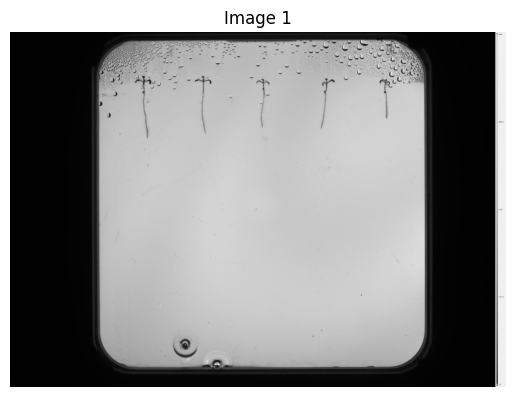

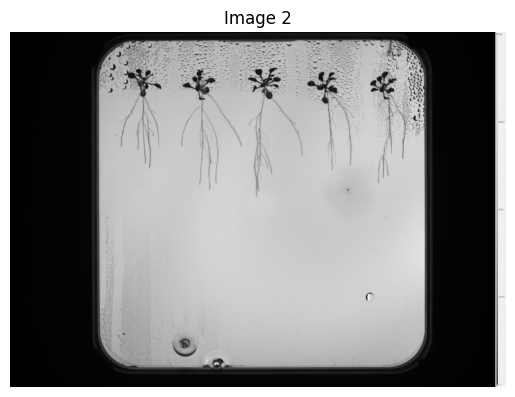

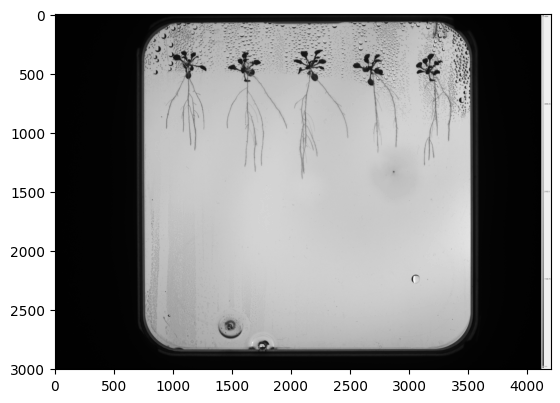

In [40]:
# Load and display the original image
image_path = "task_3_image_1.png"
plt.figure()
plt.title("Image 1")
plt.imshow(cv2.imread(image_path, 0), cmap='gray')
plt.axis("off")
plt.show()

image_path = "task_3_image_2.png"
plt.figure()
plt.title("Image 2")
plt.imshow(cv2.imread(image_path, 0), cmap='gray')
plt.axis("off")
plt.show()
plt.imshow(cv2.imread(image_path, 0), cmap='gray')

---

### Plant Instance Segmentation

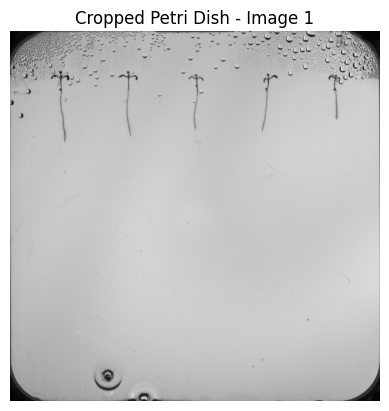

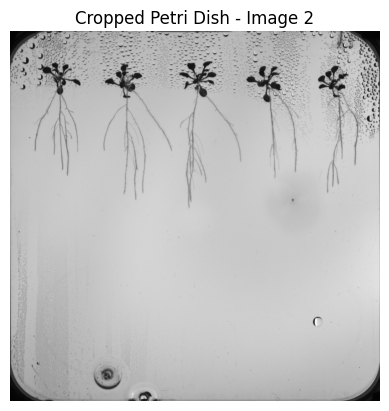

In [41]:
# Step 1: Crop image 2
image_path_1 = "task_3_image_1.png"
cropped_1 = detect_and_crop_petri_dish(image_path_1)

plt.figure()
plt.title("Cropped Petri Dish - Image 1")
plt.imshow(cv2.cvtColor(cropped_1, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# Step 1: Crop image 2
image_path_2 = "task_3_image_2.png"
cropped_2 = detect_and_crop_petri_dish(image_path_2)

plt.figure()
plt.title("Cropped Petri Dish - Image 2")
plt.imshow(cv2.cvtColor(cropped_2, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

---

### Iteration 1: Convert the image to grayscale

* Purpose: Convert the cropped images to grayscale for further processing. This simplifies image data and prepares it for binary operations.

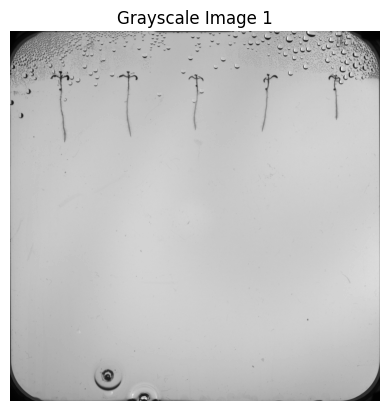

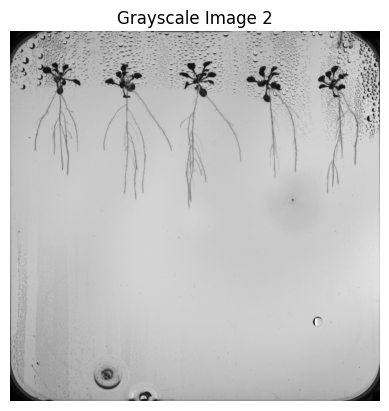

In [42]:
# Convert the cropped image to grayscale
grayscale = cv2.cvtColor(cropped_1, cv2.COLOR_BGR2GRAY)

# Convert the first cropped image to grayscale
grayscale_1 = cv2.cvtColor(cropped_1, cv2.COLOR_BGR2GRAY)

plt.figure()
plt.title("Grayscale Image 1")
plt.imshow(grayscale_1, cmap='gray')
plt.axis("off")
plt.show()

# Convert the second cropped image to grayscale
grayscale_2 = cv2.cvtColor(cropped_2, cv2.COLOR_BGR2GRAY)

plt.figure()
plt.title("Grayscale Image 2")
plt.imshow(grayscale_2, cmap='gray')
plt.axis("off")
plt.show()

---

### Iteration 2: Apply median blur to remove noise

* Purpose: Apply median blur to smooth the grayscale image and remove salt-and-pepper noise.

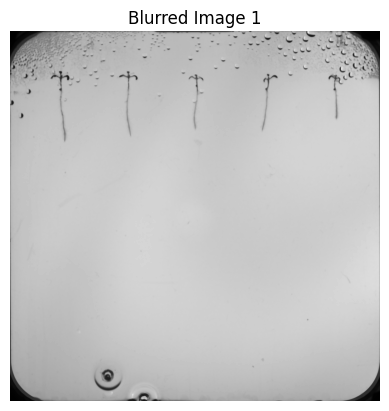

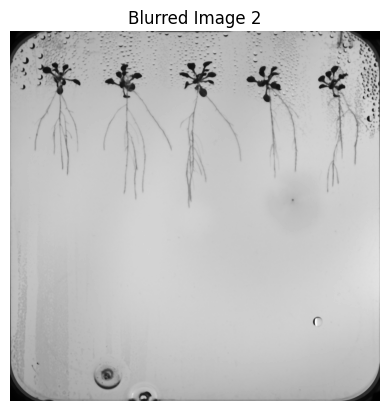

In [43]:
# Apply median blur for noise reduction on the first grayscale image
blurred_1 = cv2.medianBlur(grayscale_1, 11)

plt.figure()
plt.title("Blurred Image 1")
plt.imshow(blurred_1, cmap='gray')
plt.axis("off")
plt.show()

# Apply median blur for noise reduction on the second grayscale image
blurred_2 = cv2.medianBlur(grayscale_2, 11)

plt.figure()
plt.title("Blurred Image 2")
plt.imshow(blurred_2, cmap='gray')
plt.axis("off")
plt.show()

### Challenges:

* Choosing the correct kernel size (11). A larger size over-smooths the image, while a smaller one retains too much noise.

---

### Iteration 3: Apply adaptive thresholding

Purpose: 

* Create a binary image using adaptive thresholding, which adjusts thresholds dynamically for local regions.

* block_size = 25 and C = 5 ensure that local variations in lighting are handled effectively.

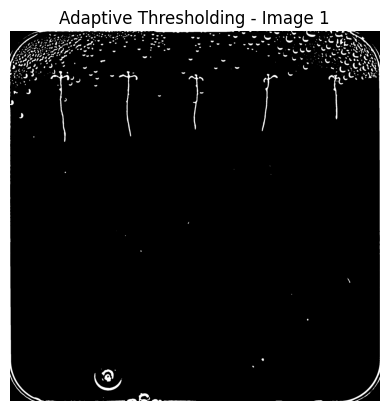

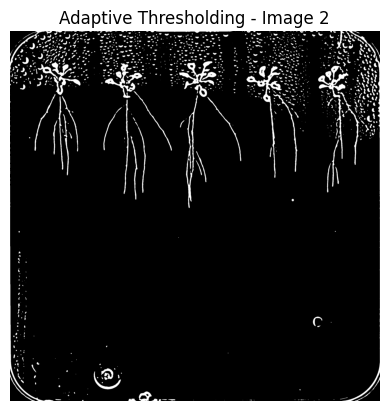

In [44]:
# Adaptive thresholding to create a binary image for the first blurred image
block_size = 35  
C = 10  
thresholded_1 = cv2.adaptiveThreshold(
    blurred_1, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, block_size, C
)

plt.figure()
plt.title("Adaptive Thresholding - Image 1")
plt.imshow(thresholded_1, cmap='gray')
plt.axis("off")
plt.show()

# Adaptive thresholding to create a binary image for the second blurred image
thresholded_2 = cv2.adaptiveThreshold(
    blurred_2, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, block_size, C
)

plt.figure()
plt.title("Adaptive Thresholding - Image 2")
plt.imshow(thresholded_2, cmap='gray')
plt.axis("off")
plt.show()

---

### Iteration 4: Create a polygon mask

* Purpose: Create a custom polygon mask that isolates the main region of interest.

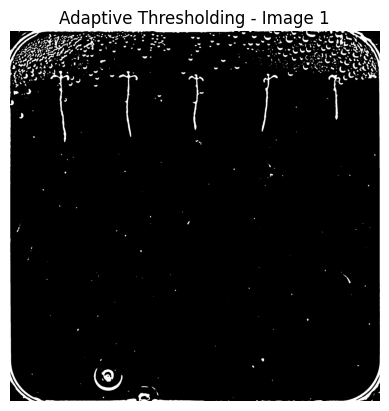

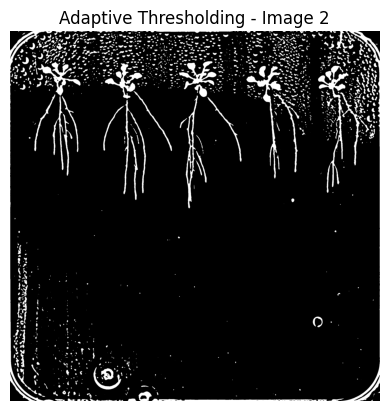

In [45]:
# Adaptive thresholding to create a binary image for the first blurred image
block_size = 51  # Increased block size for less aggressive thresholding
C = 5  # Decreased constant for less aggressive thresholding
thresholded_1 = cv2.adaptiveThreshold(
    blurred_1, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, block_size, C
)

plt.figure()
plt.title("Adaptive Thresholding - Image 1")
plt.imshow(thresholded_1, cmap='gray')
plt.axis("off")
plt.show()

# Adaptive thresholding to create a binary image for the second blurred image
thresholded_2 = cv2.adaptiveThreshold(
    blurred_2, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, block_size, C
)

plt.figure()
plt.title("Adaptive Thresholding - Image 2")
plt.imshow(thresholded_2, cmap='gray')
plt.axis("off")
plt.show()


Challenges:

* Calculating the polygon points to suit various image sizes. This was fixed by using relative percentages of the image dimensions.

---

### Iteration 5: Apply Mask and Filter Small Objects

Purpose:

* Apply the polygon mask to clean up unwanted regions.
* Remove small objects based on area using cv2.connectedComponentsWithStats.

Key Parameters:

* min_size = 1800 ensures only large components are retained.

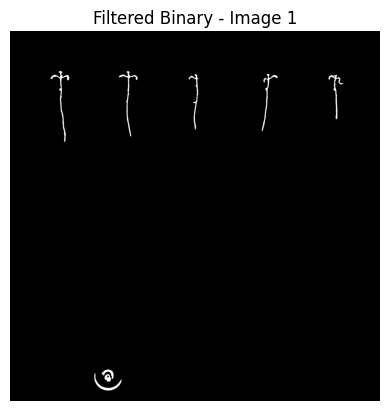

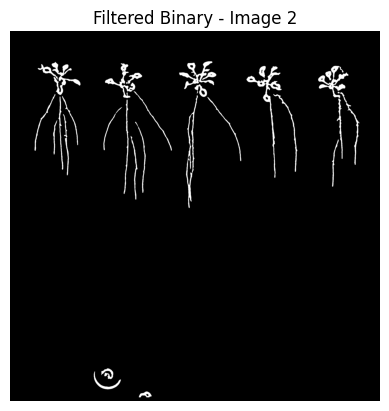

In [46]:
# Apply Mask and Filter Small Objects
num_labels_1, labels_1, stats_1, _ = cv2.connectedComponentsWithStats(masked_cleaned_1)

# Set the minimum size for valid objects
min_size = 1800
filtered_binary_1 = np.zeros_like(masked_cleaned_1)

for i in range(1, num_labels_1):  # Skip the background (label=0)
    if stats_1[i, cv2.CC_STAT_AREA] >= min_size:
        filtered_binary_1[labels_1 == i] = 255

plt.figure()
plt.title("Filtered Binary - Image 1")
plt.imshow(filtered_binary_1, cmap='gray')
plt.axis("off")
plt.show()

# Apply Mask and Filter Small Objectse
num_labels_2, labels_2, stats_2, _ = cv2.connectedComponentsWithStats(masked_cleaned_2)

filtered_binary_2 = np.zeros_like(masked_cleaned_2)

for i in range(1, num_labels_2):  # Skip the background (label=0)
    if stats_2[i, cv2.CC_STAT_AREA] >= min_size:
        filtered_binary_2[labels_2 == i] = 255

plt.figure()
plt.title("Filtered Binary - Image 2")
plt.imshow(filtered_binary_2, cmap='gray')
plt.axis("off")
plt.show()

---

### Iteration 6: Bottom Region Processing

* Purpose: Focus processing on the bottom 60% of the image.

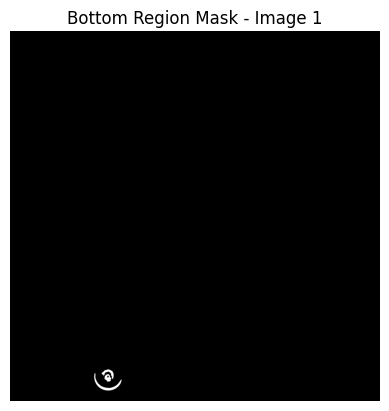

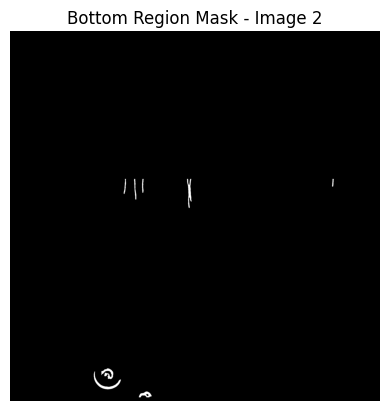

In [47]:
# Process the bottom region of the first image
# Create a mask for the bottom part of the first image
h1, w1 = filtered_binary_1.shape
bottom_mask_1 = np.zeros_like(filtered_binary_1)
bottom_mask_1[int(0.4 * h1):, :] = 255  # 60% of the image bottom

# Apply the mask to the binary image
bottom_objects_1 = cv2.bitwise_and(filtered_binary_1, bottom_mask_1)

plt.figure()
plt.title("Bottom Region Mask - Image 1")
plt.imshow(bottom_objects_1, cmap='gray')
plt.axis("off")
plt.show()

# Process the bottom region of the second image
# Create a mask for the bottom part of the second image
h2, w2 = filtered_binary_2.shape
bottom_mask_2 = np.zeros_like(filtered_binary_2)
bottom_mask_2[int(0.4 * h2):, :] = 255  # 60% of the image bottom

# Apply the mask to the binary image
bottom_objects_2 = cv2.bitwise_and(filtered_binary_2, bottom_mask_2)

plt.figure()
plt.title("Bottom Region Mask - Image 2")
plt.imshow(bottom_objects_2, cmap='gray')
plt.axis("off")
plt.show()

* Challenges:

Ensuring the bottom mask aligns correctly with the processed binary image dimensions.

---

### Iteration 7: Filtering Structures

* Purpose:

Identify and retain thin structures while removing larger noise components based on area and aspect ratio.
Parameters:

* Objects with area <= 50000 and aspect ratio <= 1.7 are considered noise.

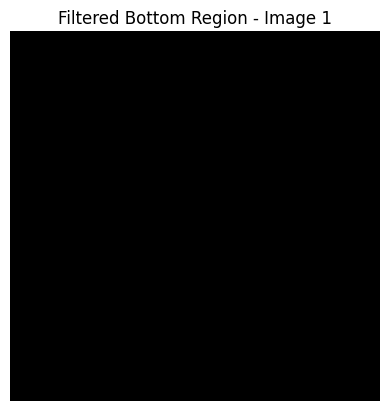

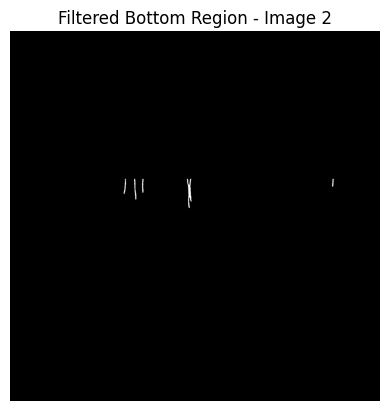

In [48]:
# Find connected components in the bottom region for the first image
num_labels_1, labels_1, stats_1, centroids_1 = cv2.connectedComponentsWithStats(bottom_objects_1)

# Filter large objects in the bottom region for the first image
filtered_bottom_1 = np.zeros_like(bottom_objects_1)
for i in range(1, num_labels_1):  # Skip the background (label=0)
    x, y, w, h, area = stats_1[i, cv2.CC_STAT_LEFT], stats_1[i, cv2.CC_STAT_TOP], \
                       stats_1[i, cv2.CC_STAT_WIDTH], stats_1[i, cv2.CC_STAT_HEIGHT], \
                       stats_1[i, cv2.CC_STAT_AREA]
    
    # Identify large noise based on area and aspect ratio
    aspect_ratio = h / w if w > 0 else 0
    is_large_object = (0 <= area <= 50000) and (0 <= aspect_ratio <= 1.7)  # Parameters for noise removal
    is_thin_structure = not is_large_object  # Other objects (e.g., roots)

    if is_thin_structure:
        filtered_bottom_1[labels_1 == i] = 255  # Keep thin structures

plt.figure()
plt.title("Filtered Bottom Region - Image 1")
plt.imshow(filtered_bottom_1, cmap='gray')
plt.axis("off")
plt.show()

# Find connected components in the bottom region for the second image
num_labels_2, labels_2, stats_2, centroids_2 = cv2.connectedComponentsWithStats(bottom_objects_2)

# Filter large objects in the bottom region for the second image
filtered_bottom_2 = np.zeros_like(bottom_objects_2)
for i in range(1, num_labels_2):  # Skip the background (label=0)
    x, y, w, h, area = stats_2[i, cv2.CC_STAT_LEFT], stats_2[i, cv2.CC_STAT_TOP], \
                       stats_2[i, cv2.CC_STAT_WIDTH], stats_2[i, cv2.CC_STAT_HEIGHT], \
                       stats_2[i, cv2.CC_STAT_AREA]
    
    # Identify large noise based on area and aspect ratio
    aspect_ratio = h / w if w > 0 else 0
    is_large_object = (0 <= area <= 50000) and (0 <= aspect_ratio <= 1.7)  # Parameters for noise removal
    is_thin_structure = not is_large_object  # Other objects (e.g., roots)

    if is_thin_structure:
        filtered_bottom_2[labels_2 == i] = 255  # Keep thin structures

plt.figure()
plt.title("Filtered Bottom Region - Image 2")
plt.imshow(filtered_bottom_2, cmap='gray')
plt.axis("off")
plt.show()

---

### Iteration 8: Combining Top and Bottom Regions

* Purpose: Combine the cleaned top and bottom regions to create the final mask.

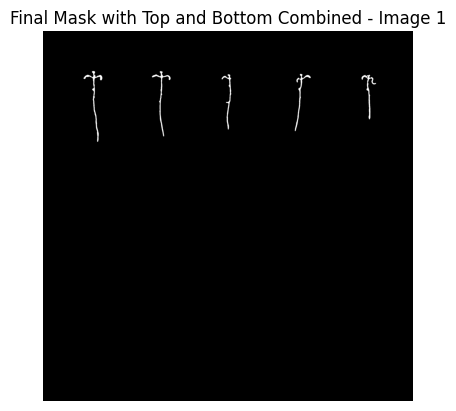

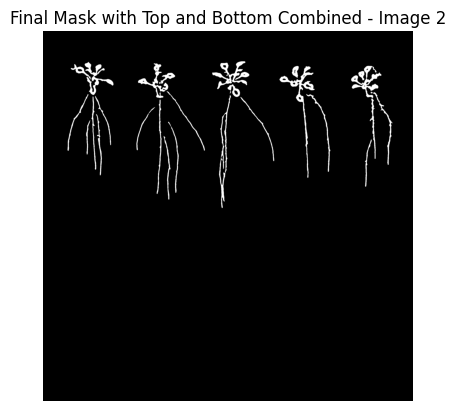

In [49]:
# Step 9: Combine the top and bottom regions of the first image
top_mask_1 = cv2.bitwise_and(filtered_binary_1, cv2.bitwise_not(bottom_mask_1))
final_mask_1 = cv2.bitwise_or(top_mask_1, filtered_bottom_1)

plt.figure()
plt.title("Final Mask with Top and Bottom Combined - Image 1")
plt.imshow(final_mask_1, cmap='gray')
plt.axis("off")
plt.show()

# Step 9: Combine the top and bottom regions of the second image
top_mask_2 = cv2.bitwise_and(filtered_binary_2, cv2.bitwise_not(bottom_mask_2))
final_mask_2 = cv2.bitwise_or(top_mask_2, filtered_bottom_2)

plt.figure()
plt.title("Final Mask with Top and Bottom Combined - Image 2")
plt.imshow(final_mask_2, cmap='gray')
plt.axis("off")
plt.show()

---

### Iteration 9: Morphological Operations

* Purpose: Refine the final mask by closing small gaps and smoothing edges using dilation and erosion.

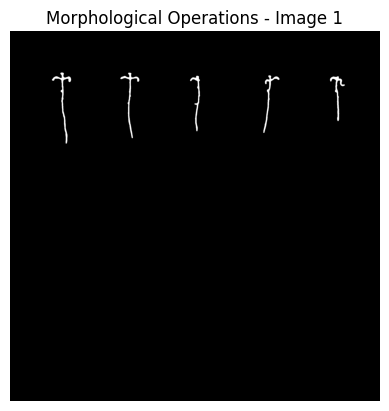

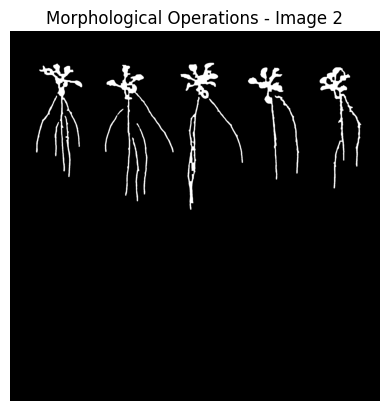

In [50]:
# Morphological operations to close gaps and refine the mask for the first image
kernel = np.ones((2, 2), dtype="uint8")
kernel2 = np.ones((6, 6), dtype="uint8")

# Closing operation to remove gaps for the first image
im_rod_d_1 = cv2.dilate(final_mask_1, kernel, iterations=8)
im_closing_e_1 = cv2.erode(im_rod_d_1, kernel2, iterations=2)

im_rod_d_1 = cv2.dilate(im_closing_e_1, kernel2, iterations=3)
im_closing_e_1 = cv2.erode(im_rod_d_1, kernel, iterations=11)

plt.figure()
plt.title("Morphological Operations - Image 1")
plt.imshow(im_closing_e_1, cmap='gray')
plt.axis("off")
plt.show()

# Closing operation to remove gaps for the second image
im_rod_d_2 = cv2.dilate(final_mask_2, kernel, iterations=8)
im_closing_e_2 = cv2.erode(im_rod_d_2, kernel2, iterations=2)

im_rod_d_2 = cv2.dilate(im_closing_e_2, kernel2, iterations=3)
im_closing_e_2 = cv2.erode(im_rod_d_2, kernel, iterations=11)

plt.figure()
plt.title("Morphological Operations - Image 2")
plt.imshow(im_closing_e_2, cmap='gray')
plt.axis("off")
plt.show()

* Challenges:

Choosing kernel sizes (2x2 and 6x6) and iterations required multiple trials to optimize the output.

---

### Iteration 10: Connected Components Visualization

* Purpose: Analyze the connected components and visualize them to confirm the segmentation is correct.

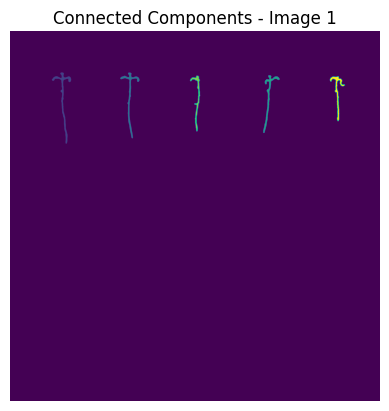

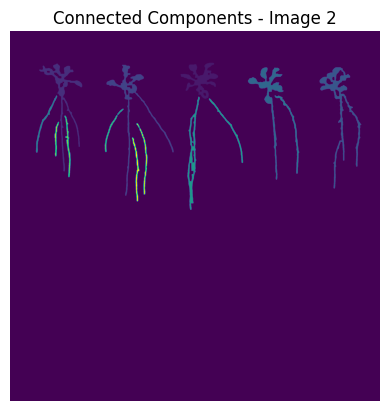

In [51]:
# Find connected components in the final mask for the first image
num_labels_1, labels_1, stats_1, centroids_1 = cv2.connectedComponentsWithStats(im_closing_e_1)

# Visualize connected components for the first image
plt.figure()
plt.title("Connected Components - Image 1")
plt.imshow(labels_1, cmap='viridis')
plt.axis("off")
plt.show()

# Find connected components in the final mask for the second image
num_labels_2, labels_2, stats_2, centroids_2 = cv2.connectedComponentsWithStats(im_closing_e_2)

# Visualize connected components for the second image
plt.figure()
plt.title("Connected Components - Image 2")
plt.imshow(labels_2, cmap='viridis')
plt.axis("off")
plt.show()

### Overall Issues and Solutions:
* Bounding Box Adjustment: Ensured square cropping by calculating the center and adjusting width/height equally.

* Adaptive Threshold Parameters: Optimized block_size and C through iterative testing.

* Noise Removal: Used connected components and morphological operations to filter irrelevant objects.

* Custom Mask Creation: Relative positioning made the mask adaptable to different image sizes.